# Estudio comparativo de algoritmos en un problema de k-armed bandit: algoritmos SoftMax, Gradiente de preferencias..

*Description:* El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.



## Preparación del entorno


In [ ]:
#@title Copiar el repositorio.

!git clone https://github.com/JoseHernandez11/k_brazos_JMHJDRJG.git
%cd k_brazos_JMHJDRJG



Cloning into 'eml_k_bandit'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 66 (delta 28), reused 42 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 318.16 KiB | 6.77 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [1]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('/content/k_brazos_JMHJDRJG')


# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm,  Softmax, GradientBandit
from arms import ArmNormal, ArmBinomial, ArmBernoulli,  Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret

# Fijar la semilla para reproducibilidad

seed = 42
np.random.seed(seed)  

['c:\\Users\\josem\\anaconda3\\envs\\EML_P1E1\\python310.zip', 'c:\\Users\\josem\\anaconda3\\envs\\EML_P1E1\\DLLs', 'c:\\Users\\josem\\anaconda3\\envs\\EML_P1E1\\lib', 'c:\\Users\\josem\\anaconda3\\envs\\EML_P1E1', '', 'c:\\Users\\josem\\anaconda3\\envs\\EML_P1E1\\lib\\site-packages', 'c:\\Users\\josem\\anaconda3\\envs\\EML_P1E1\\lib\\site-packages\\win32', 'c:\\Users\\josem\\anaconda3\\envs\\EML_P1E1\\lib\\site-packages\\win32\\lib', 'c:\\Users\\josem\\anaconda3\\envs\\EML_P1E1\\lib\\site-packages\\Pythonwin', '/content/k_brazos_JMHJDRJG']


### Definición del ejecutador de experimentos.

Cada algoritmo de los que se van a comparar se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
La función base *run_experiment* ha sido modificada respecto a la proporcionada como base, haciendo que devuelva información extra que nos permitirá crear todas las gráficas pedidas en el enunciado de la práctica. De esta forma, podremos comparar:

* Evolución de la recompensa promedia respecto al número de iteraciones entre los diferentes algoritmos y configuraciones.
* Evolución del porcentaje de selecciones óptimas respecto al número de iteraciones entre los diferentes algoritmos y configuraciones.
* Estadísticas de los brazos (veces seleccionado, recompensa del brazo, cúal es el óptimo) por cada algoritmo y configuración.
* Evolución del regret acumulado promedio respecto al número de iteraciones entre los diferentes algoritmos y configuraciones.

Para Softmax emperimentaremos con tres valores para la temperatura $\tau=[0.1,1,10]$, mientras que para el gradiente de preferencias nos limitaremos a probar $\alpha=0.1$ como hemos explicado en la sección anterior (parte documental, Sección 3: Algoritmos.).

In [2]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.
    
    regret_accumulated = np.zeros((len(algorithms), steps))  # Matriz para almacenar el rechazo promedio.

    arm_stats = np.zeros((len(algorithms), bandit.k, steps))  # Matriz para almacenar las estadísticas de los brazos.

    selected_arms = np.zeros ((len(algorithms), bandit.k)) # Matriz para almacenar los brazos seleccionados.

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                regret_accumulated[idx, step] = regret_accumulated[idx, step - 1] + (current_bandit.pull_arm(optimal_arm) - reward) if step > 0 else (current_bandit.pull_arm(optimal_arm) - reward)

                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1

                for arm in range(bandit.k):
                    arm_stats[idx, arm, step] = current_bandit.pull_arm(arm)
                    if arm == chosen_arm:
                        selected_arms[idx, arm] += 1

    rewards /= runs
    optimal_selections /= runs
    regret_accumulated /= runs
    
    arm_stats_mean = arm_stats.mean(axis=2)
    arm_stats_lists = []  # Lista de diccionarios para almacenar las estadísticas de los brazos.

    for algo in range(len(algorithms)):
        arm_stats_dict = {}
        for arm in range(bandit.k):
            arm_stats_dict[arm+1] = {  # Diccionario para almacenar las estadísticas de cada uno de los brazos.
                "avg_reward": arm_stats_mean[algo, arm],
                "times_selected": round(selected_arms[algo, arm] / runs),
                "optimal_arm": 1 if arm == optimal_arm else 0
            }
        arm_stats_lists.append(arm_stats_dict)

        
    return rewards, optimal_selections, arm_stats_lists, regret_accumulated


## Ejecución del experimento para distribución normal



In [3]:
## Parámetros del experimento

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [Softmax(k, tau=0.1), Softmax(k, tau=1), Softmax(k, tau=10), GradientBandit(k, alpha=0.1)]  # Lista de algoritmos a comparar

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, arm_stats_list, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)


Optimal arm: 8 with expected reward=9.56


### Visualización de los resultados.

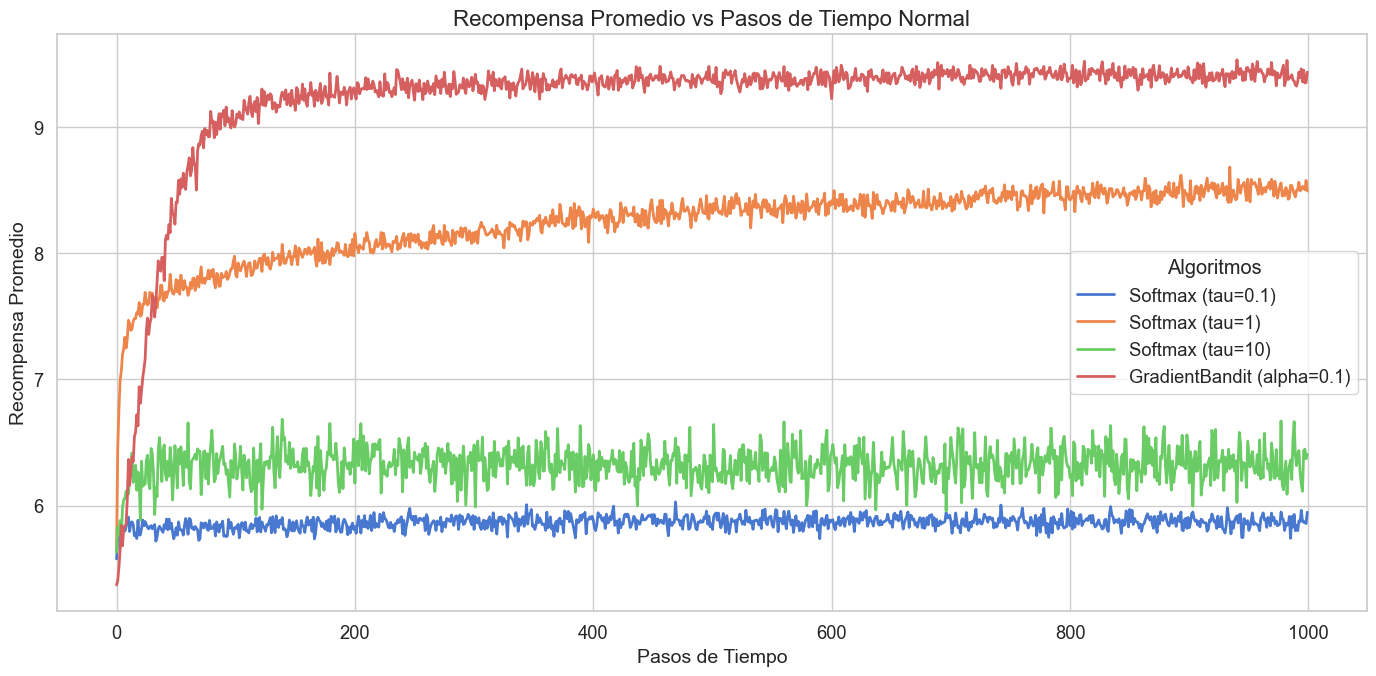

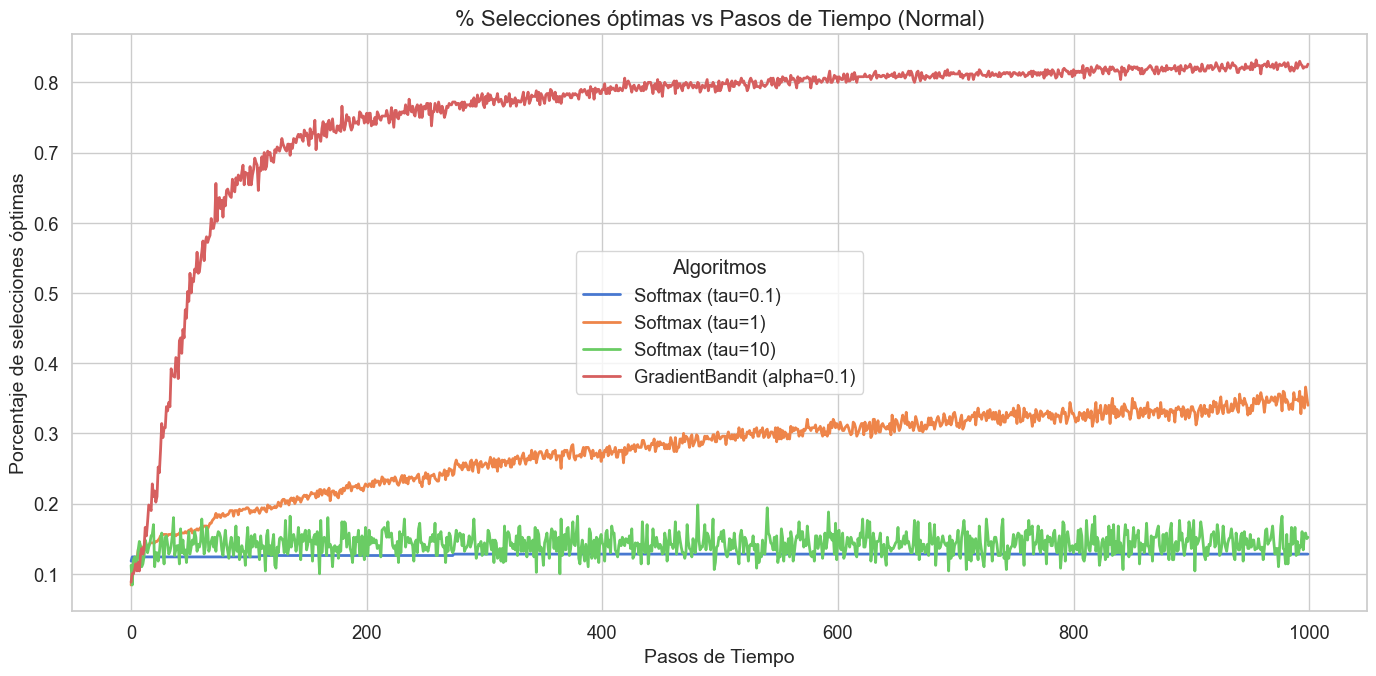

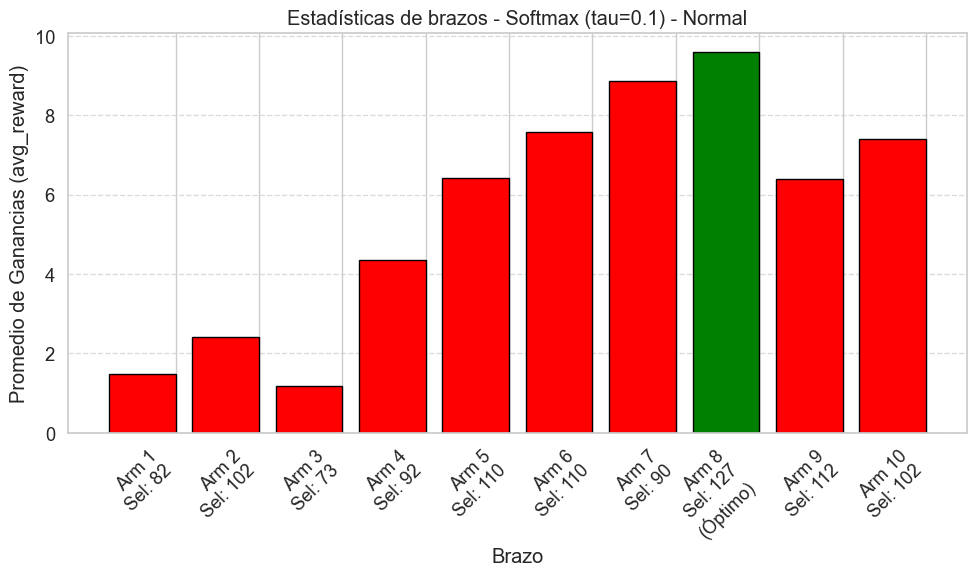

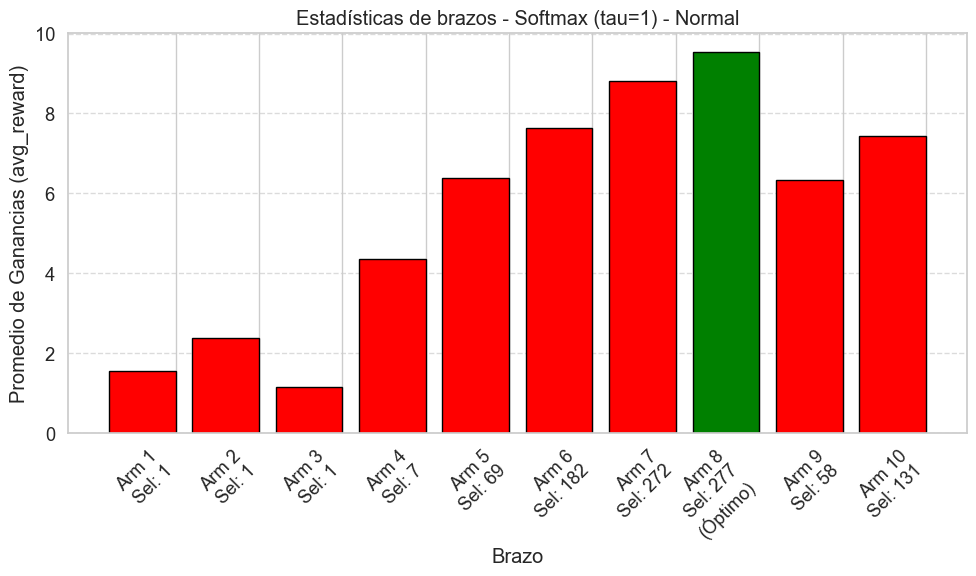

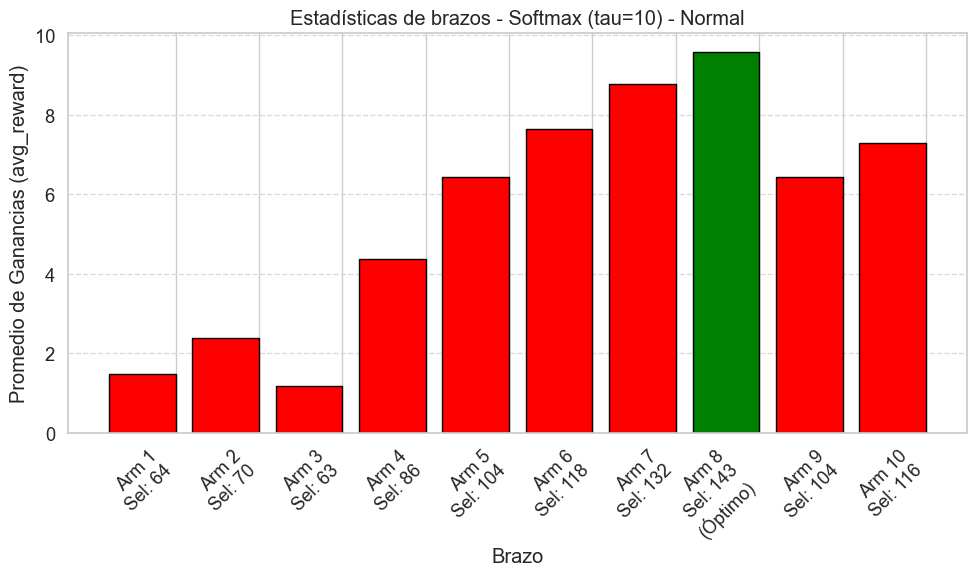

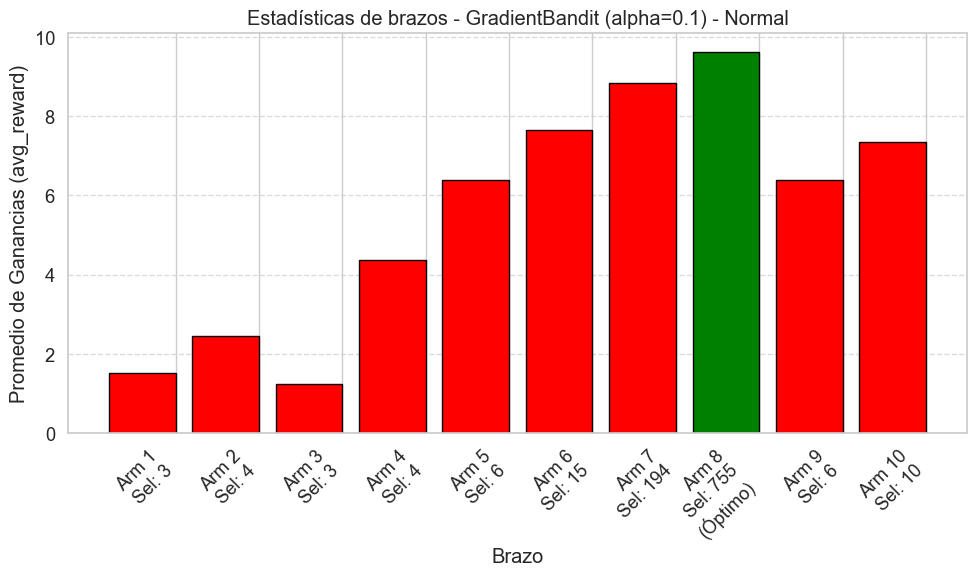

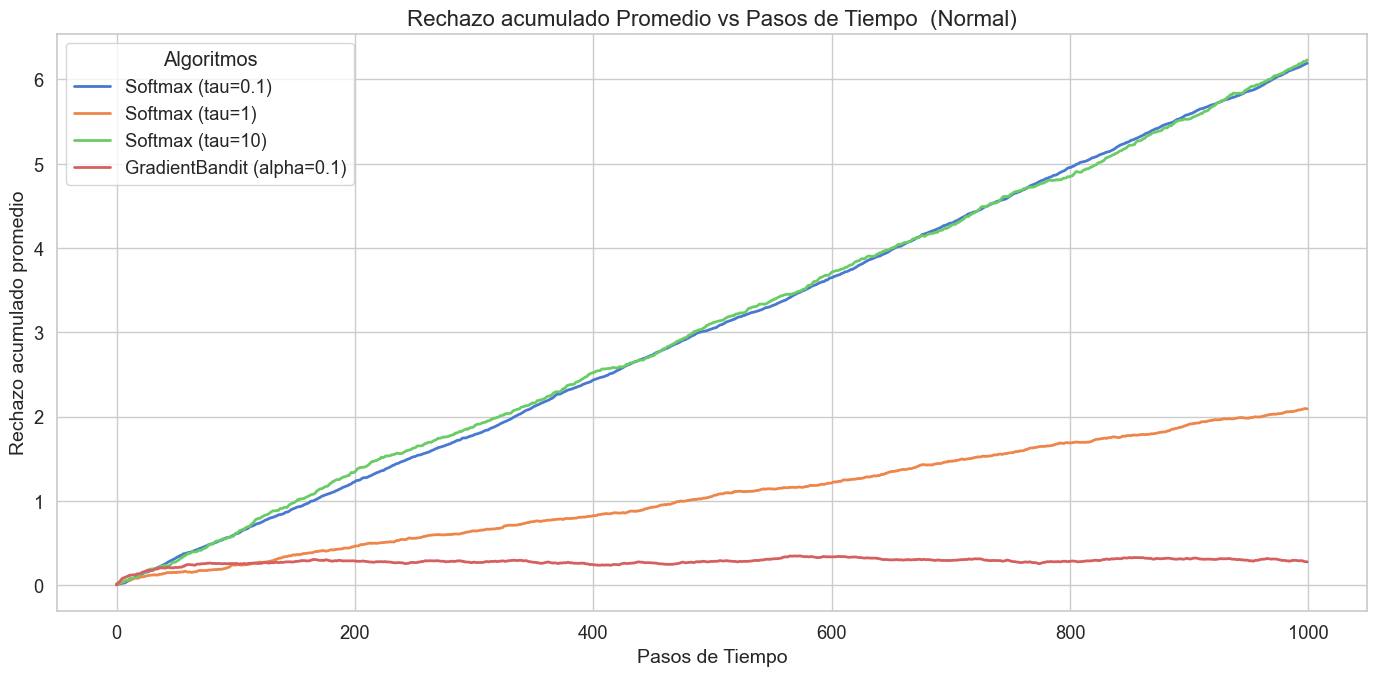

In [4]:

# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arm_stats_list, algorithms)
plot_regret(steps, regret_accumulated, algorithms)


### Análisis de los resultados.

En las gráficas, podemos observar como se comportan los distintos algoritmos basados en gradientes con una distribución normal de las recopensas de los brazos. Vemos que el algoritmo Softmax, en cualquiera de sus configuraciones obtiene unos resultados considerablemente peores a los del gradiente de preferencias. Los mejores resultados para este algoritmo se obtienen cuando se opta por un $\tau=1$, considerado la configuración estándar, consiguiendo las configuraciones muy exploratorias ($\tau$ grande) o muy explotatorias ($\tau$ pequeño) un desempeño muy malo: porcentaje de selecciones óptimas $0.1$ (las veces que de primeras elige el brazo bueno) y curvas de rechazo acumulado que crecen de forma lineal con $t$. 

## Experimento para bandido distribución Bernoulli

In [5]:
# Parámetros del experimento

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución Bernoulli

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [Softmax(k, tau=0.1), Softmax(k, tau=1), Softmax(k, tau=10), GradientBandit(k, alpha=0.1)]  # Lista de algoritmos a comparar

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, arm_stats_list, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)


Optimal arm: 2 with expected reward=0.81


### Visualización de los resultados.

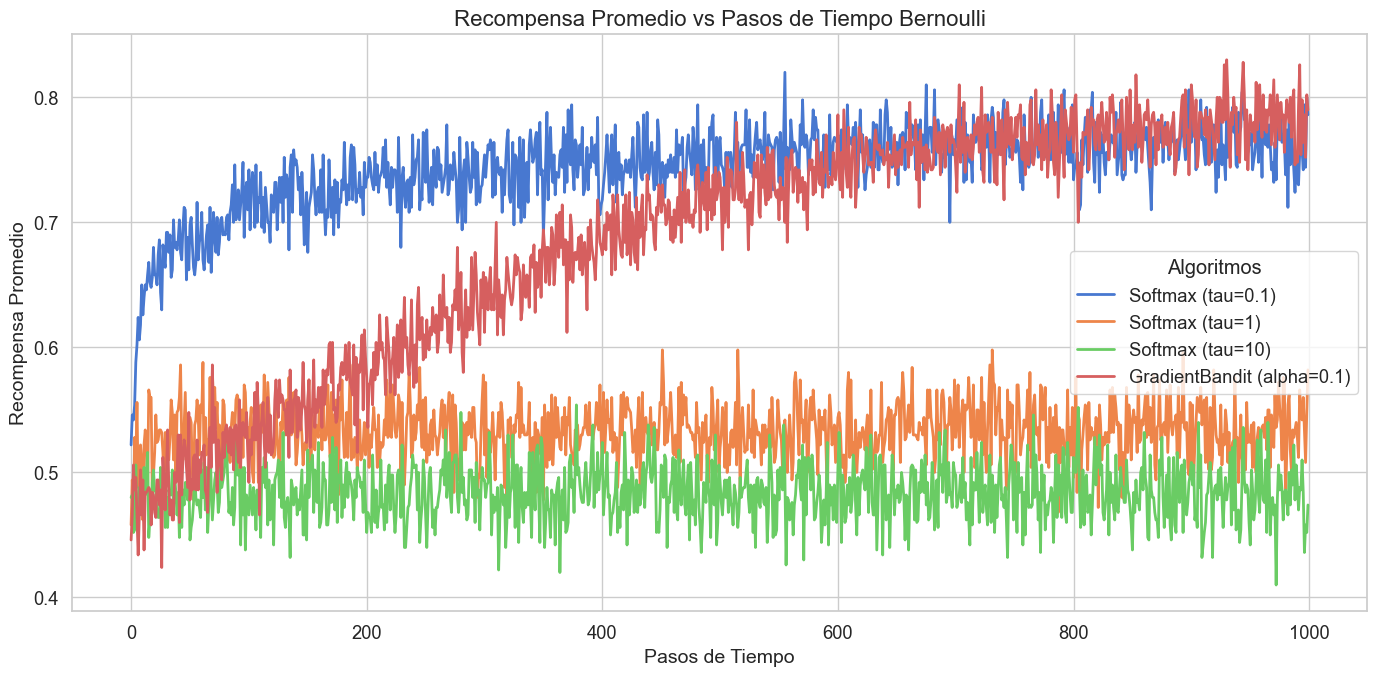

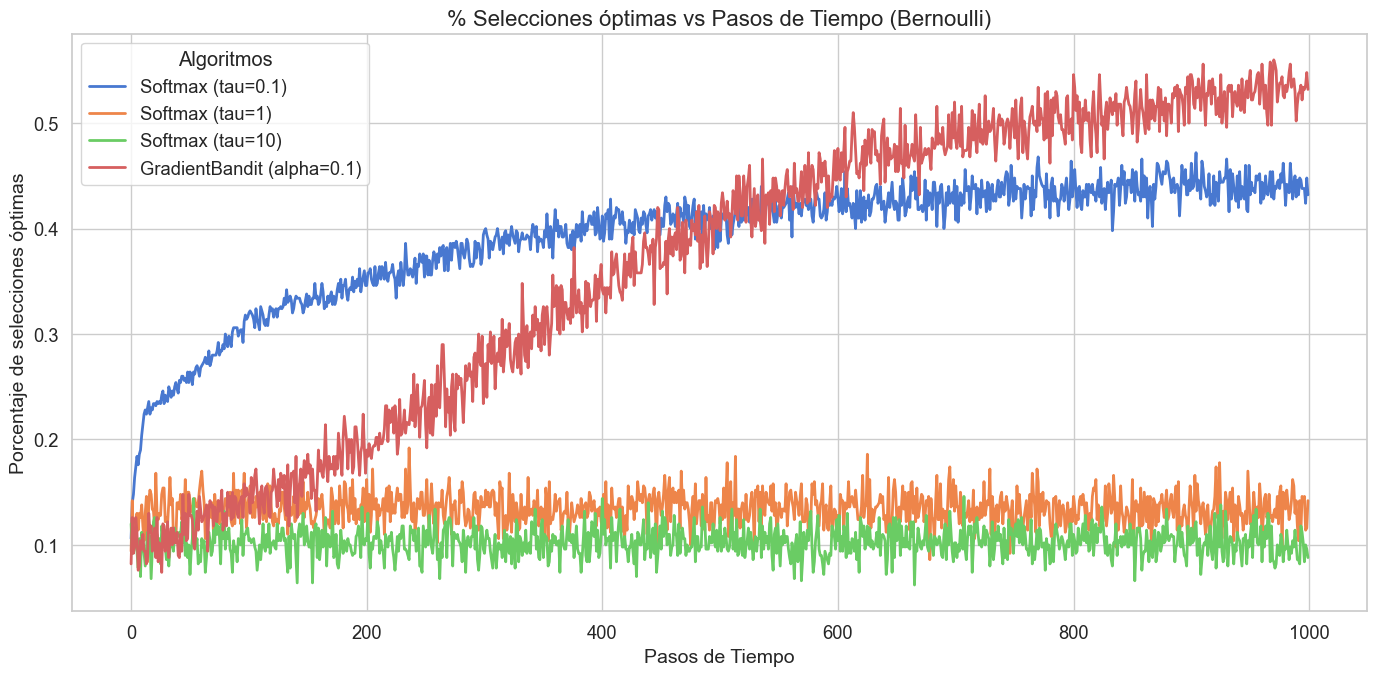

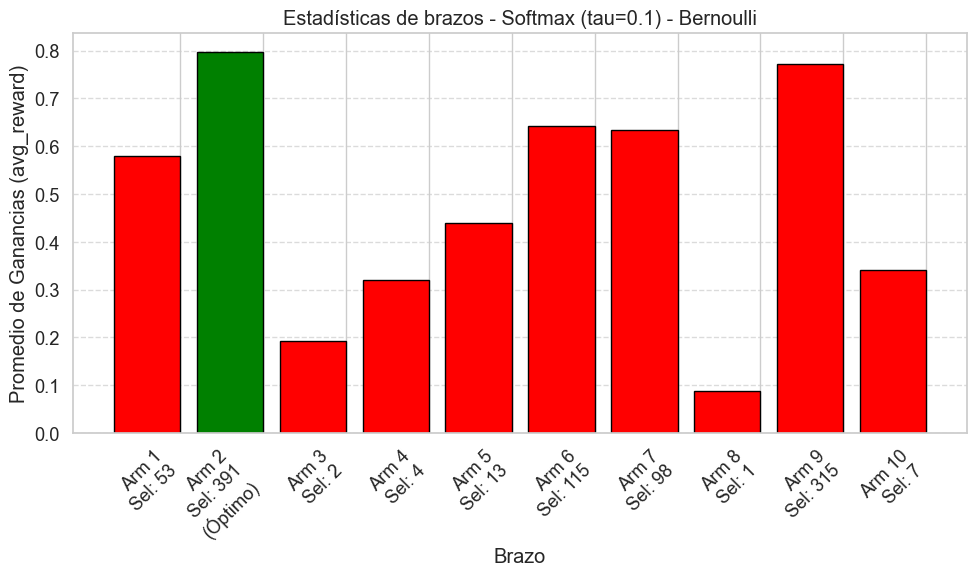

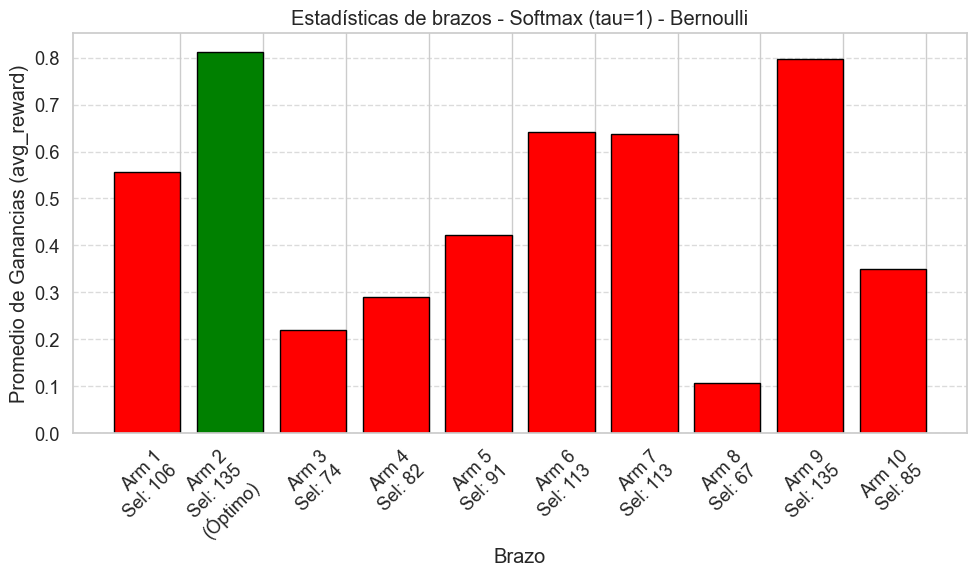

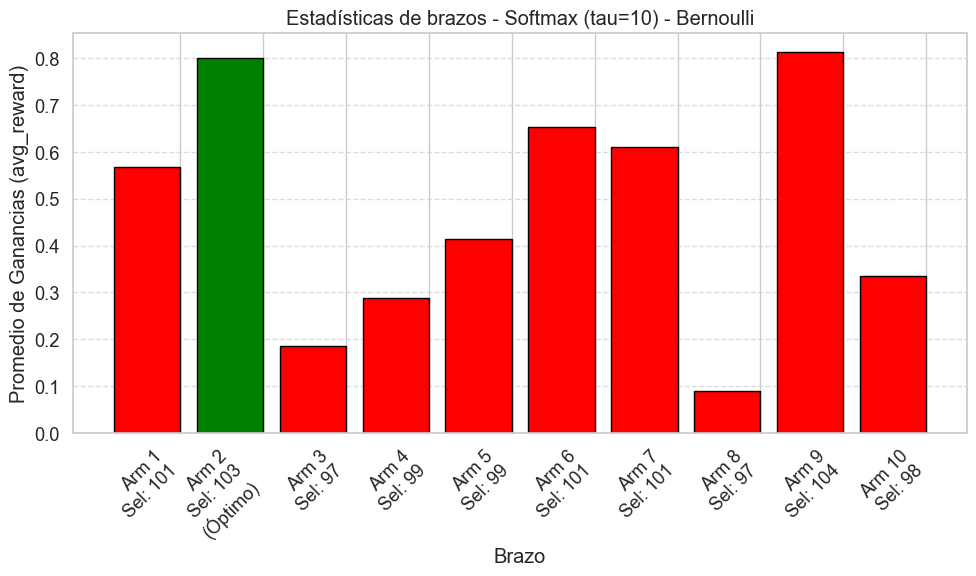

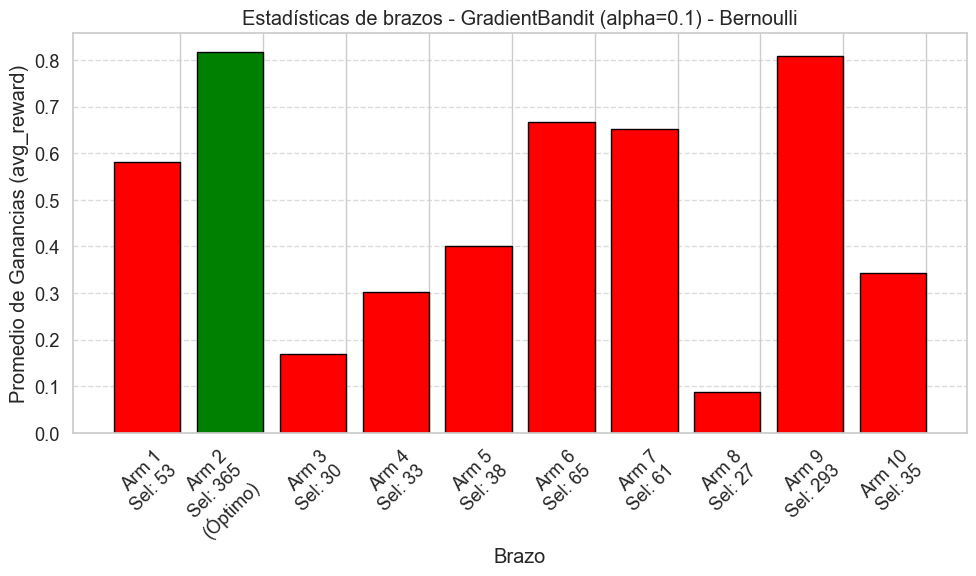

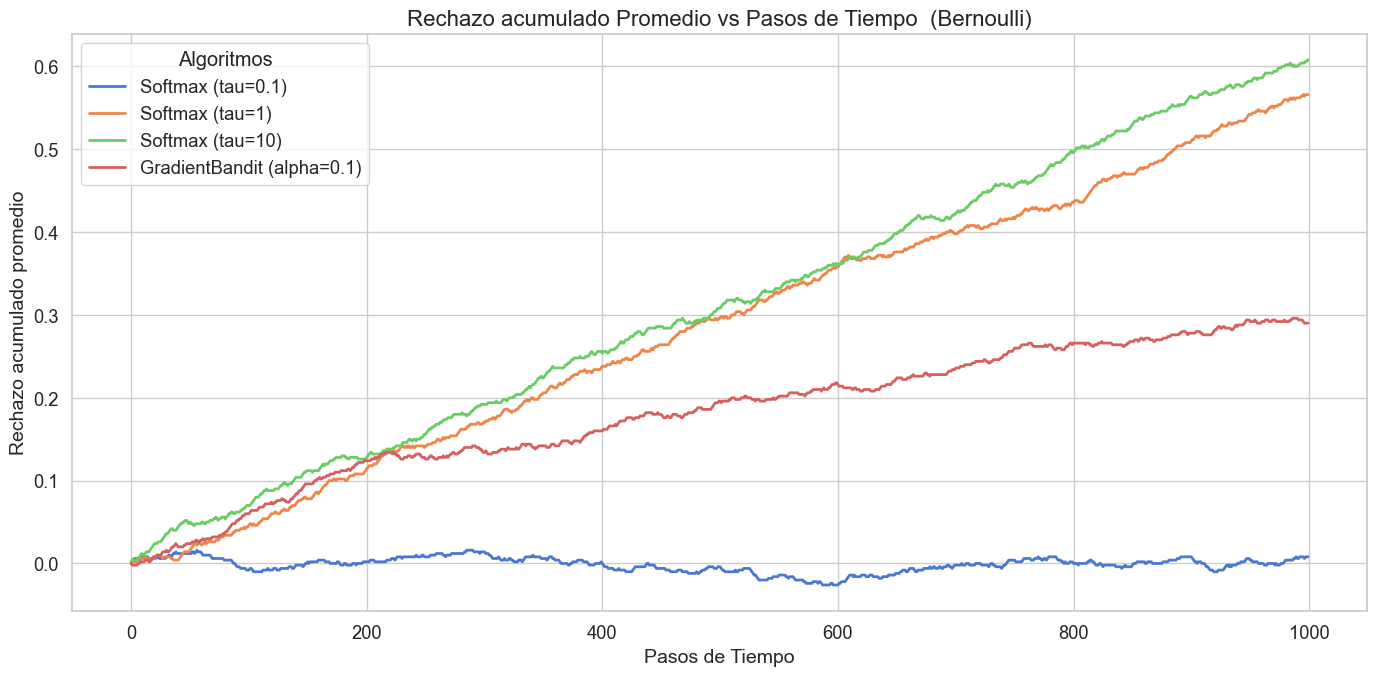

In [6]:

# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms, dist="Bernoulli")
plot_optimal_selections(steps, optimal_selections, algorithms, dist="Bernoulli")
plot_arm_statistics(arm_stats_list, algorithms, dist="Bernoulli")
plot_regret(steps, regret_accumulated, algorithms, dist="Bernoulli")


### Análisis de los resultados.
Observando las gráficas de la Figura 8, vemos que el gradiente de preferencia sigue siendo el ganador en el porcentaje de selecciones óptimas, aunque sorprende el gran desempeño de Softmax para $\tau=0.1$, consiguiendo superar incluso al gradiente de preferencias en el caso del regret acumulado, mientras que los otros valores de $\tau$ obtienen resultados paupérrimos. Este fenómeno puede deberse a la propia distribución de Bernoulli, al ser las recompensas binarias $ (0 \text{ o } 1) $, los valores de la recompesa esperada de cada brazo se estabilizan rápido y una estrategia de explotación fuerte (bajo $ \tau $) converge rápido hacia el mejor brazo.






## Ejecución del experimento para distribución binomial.

In [7]:
# Parámetros del experimento

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k, n=5)) # Generar un bandido con k brazos de distribución binomial

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [Softmax(k, tau=0.1), Softmax(k, tau=1), Softmax(k, tau=10), GradientBandit(k, alpha=0.1)]  # Lista de algoritmos a comparar

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, arm_stats_list, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)

Optimal arm: 8 with expected reward=4.1


### Visualización de los resultados.


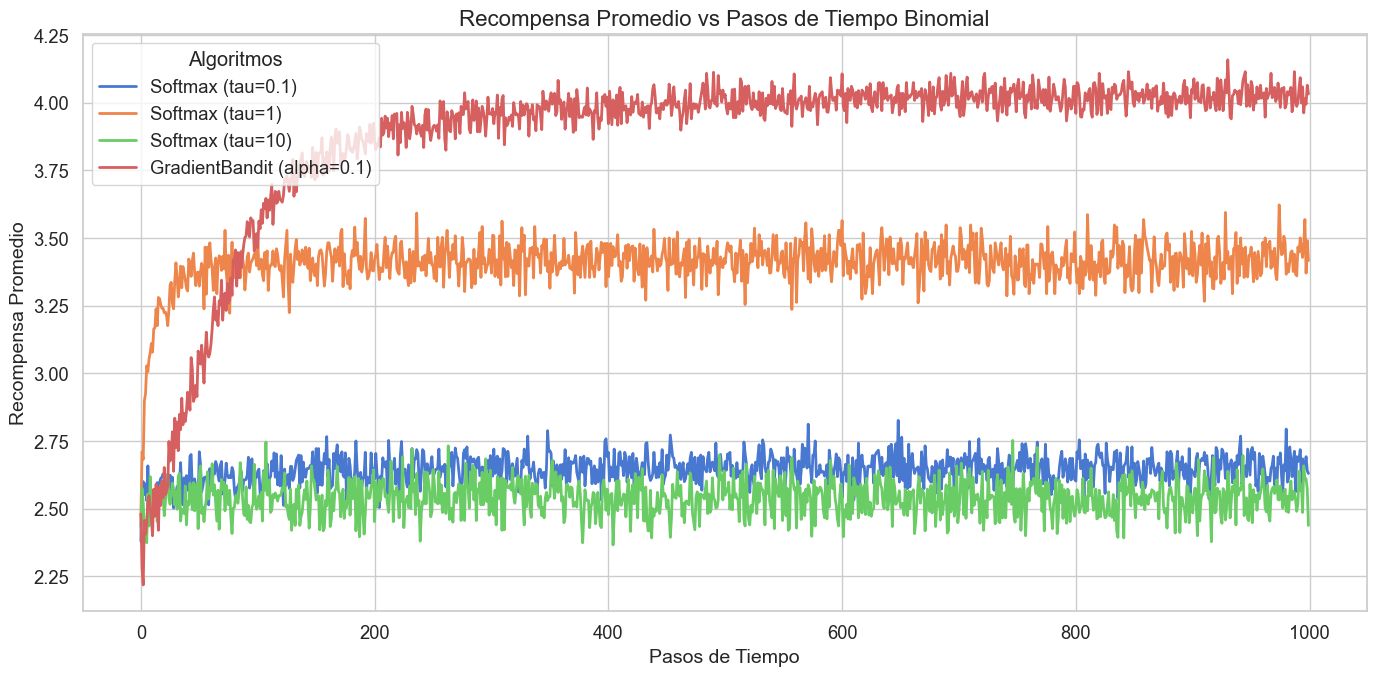

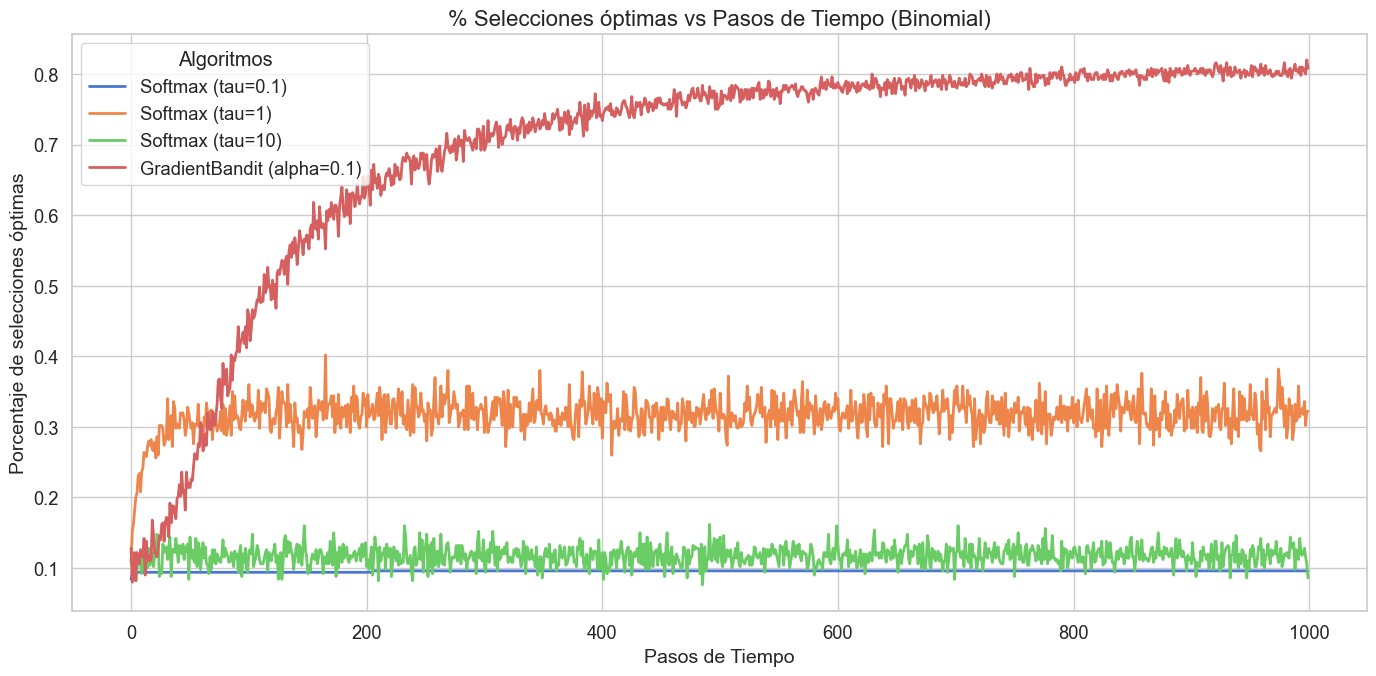

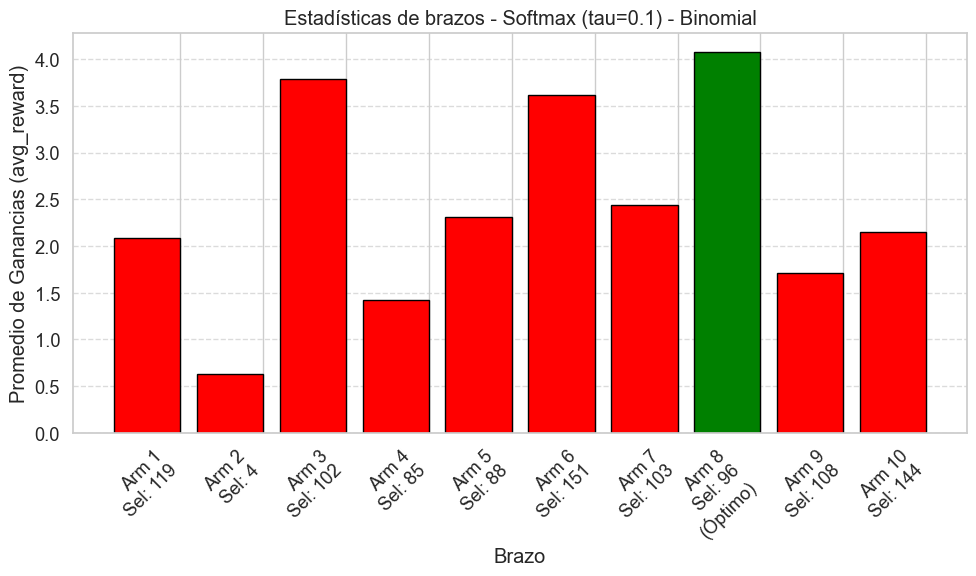

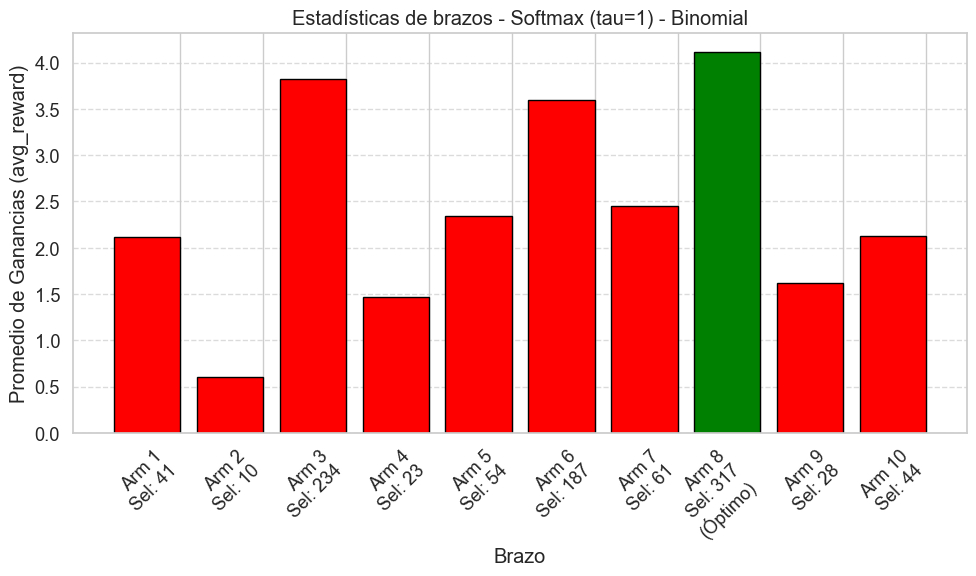

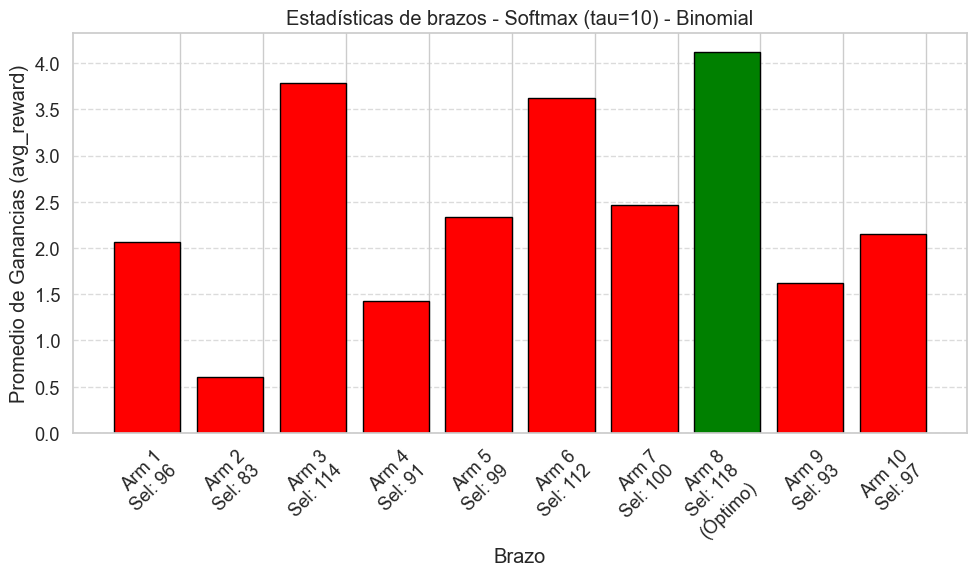

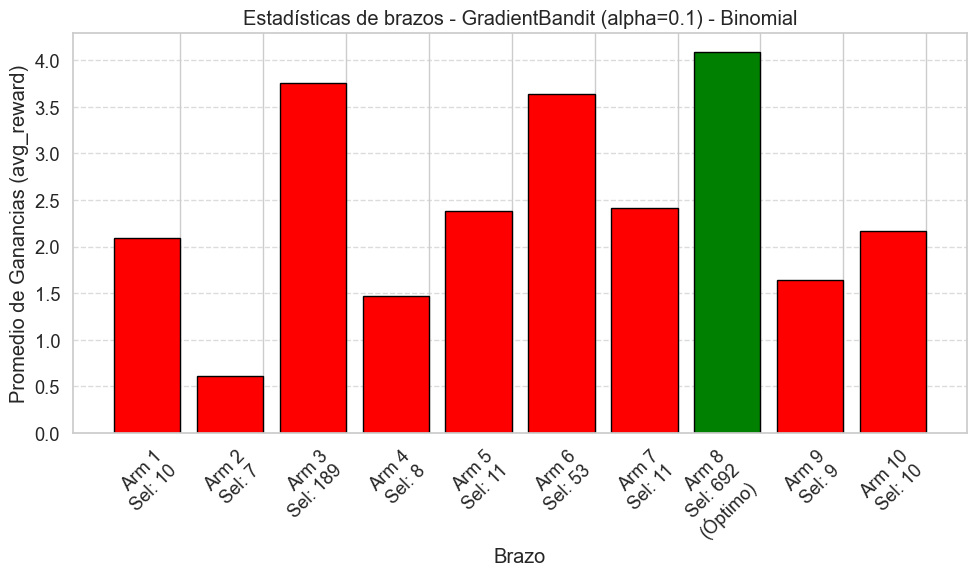

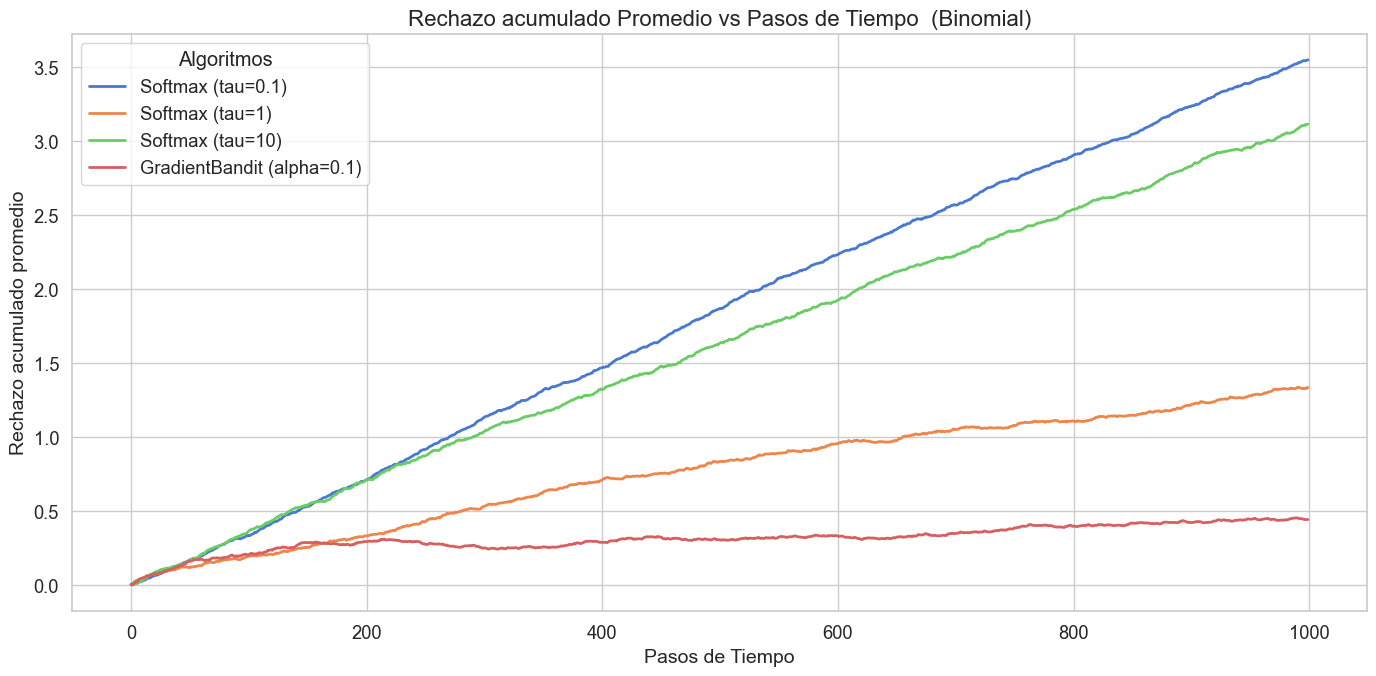

In [8]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms, dist="Binomial")
plot_optimal_selections(steps, optimal_selections, algorithms, dist="Binomial")
plot_arm_statistics(arm_stats_list, algorithms, dist="Binomial")
plot_regret(steps, regret_accumulated, algorithms, dist="Binomial")

### Análisis de los resultados

Para el caso de la distribución binomial en los algoritmos basados en gradientes vuelven a darse curvas muy similares a las que ya hemos comentado para la distribución normal.

## Conclusiones

En cuanto a los resultados globales de la familia de algoritmos basados en el gradiente, podemos detectar que el gradiente de preferencias es la configuración más consistente y que consigue obtener los mejores resultados en todas las distribuciones. En cuanto a la función softmax, un parámetro de temperatura estándar $\tau=1$, resulta más adecuado para las distribuciones normal y binomial, mientras que una configuración casi exclusivamente explotatoria ($\tau=0.1$)destaca en el caso de Bernoulli. La configuración altamente exploratoria obtiene muy malos resultados ($\tau=10$) para todas las distribuciones. Para el experimento final, usaremos el gradiente de preferencias con $\alpha=0.1$ (estándar) como mejor representante de los algoritmos basados en el gradiente.